
Radiobiology Metrics
---------------------
gEUD: 26.154265035624782
BED-EUD: 53.892420687755106
NTCP: 0.248689357800066


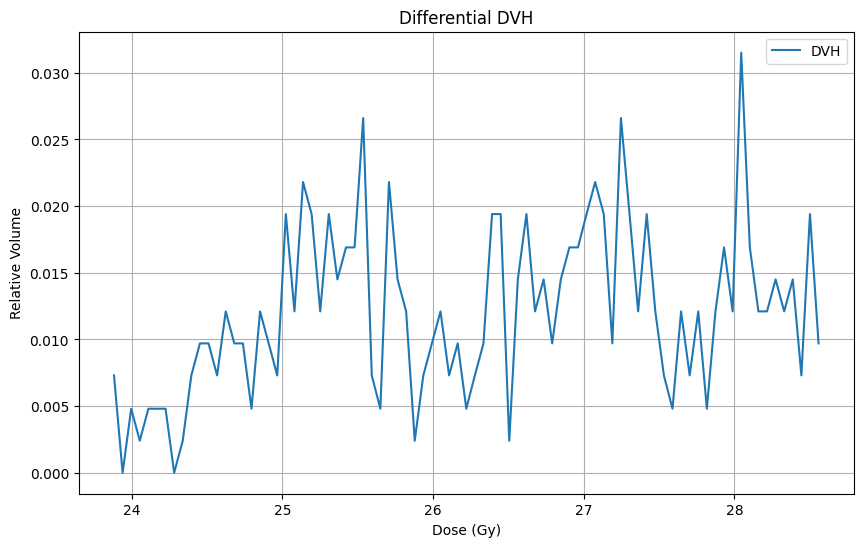

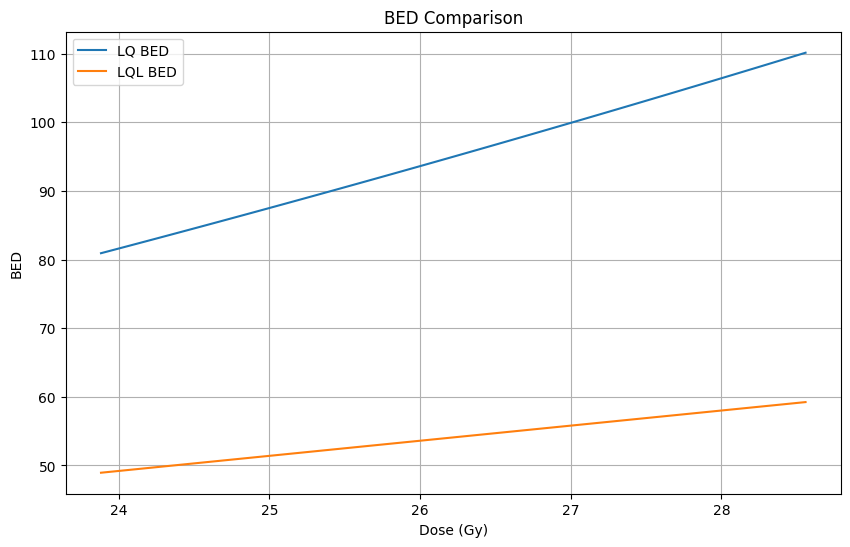

In [6]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm


# ==============================
# 1. Load DVH JSON
# ==============================

def load_dvh(json_file):

    with open(json_file, 'r') as f:
        data = json.load(f)
    dvh = data["DvhData"][0]["DvhList"]

    dose = []
    vol = []

    for p in dvh:

        d = float(p["dose"].replace(" cGy",""))/100.0
        v = float(p["relativeVolume"].replace("%",""))/100.0
    
        dose.append(d)
        vol.append(v)

    dose = np.array(dose)
    vol = np.array(vol)



    df = pd.DataFrame({
        "Dose_Gy": dose,
        "Volume": vol
    })

    return df


# ==============================
# 2. Radiobiology Models
# ==============================

def LQ_BED(d, n, alpha_beta):
    """
    Linear Quadratic BED
    """
    return n * d * (1 + d/alpha_beta)


def LQL_BED(d, n, alpha_beta, Dt):
    """
    Linear Quadratic Linear BED
    Astrahan model
    """

    if d <= Dt:
        return n * d * (1 + d/alpha_beta)

    else:
        bed_per_fx = d * (1 + 2 * Dt / alpha_beta) - (Dt**2 / alpha_beta)
        return n * bed_per_fx

def calc_bed_usc(total_dose, n, ab, dt):
    """USC (Universal Survival Curve) 模型 BED 计算"""
    d = total_dose / n
    if d <= dt:
        # 低剂量区使用 LQ 模型
        return total_dose * (1 + d / ab)
    else:
        # 高剂量区进入线性阶段 (LQL 模型形式)
        # 公式: BED_fx = [d(1 + 2*Dt/ab) - Dt^2/ab]
        bed_per_fx = d * (1 + 2 * dt / ab) - (dt**2 / ab)
        return n * bed_per_fx


# ==============================
# 3. gEUD
# ==============================

def compute_gEUD(dose, vol, a):

    dose = np.array(dose)
    vol = np.array(vol)

    return (np.sum(vol * dose**a))**(1/a)


# ==============================
# 4. BED-weighted EUD
# ==============================

def compute_BED_EUD(BED, vol, a):

    return (np.sum(vol * BED**a))**(1/a)


# ==============================
# 5. NTCP (Lyman-Kutcher-Burman)
# ==============================

def compute_NTCP(EUD, TD50, m):

    t = (EUD - TD50) / (m * TD50)

    return norm.cdf(t)


# ==============================
# 6. DVH Radiobiology Pipeline
# ==============================

def radiobiology_pipeline(df,
                          n_fraction=30,
                          alpha_beta=3,
                          Dt=6.0,
                          a=8,
                          TD50=60,
                          m=0.15):


    dose = df["Dose_Gy"].values
    vol  = df["Volume"].values


    # dose per fraction
    d = dose / n_fraction


    # LQ BED
    BED_LQ = np.array([
        LQ_BED(di, n_fraction, alpha_beta) for di in d
    ])


    # LQL BED
    BED_LQL = np.array([
        LQL_BED(di, n_fraction, alpha_beta, Dt) for di in d
    ])


    # gEUD
    gEUD = compute_gEUD(dose, vol, a)


    # BED weighted EUD
    BED_EUD = compute_BED_EUD(BED_LQL, vol, a)


    # NTCP
    NTCP = compute_NTCP(BED_EUD, TD50, m)


    results = {
        "gEUD": gEUD,
        "BED_EUD": BED_EUD,
        "NTCP": NTCP
    }

    df["BED_LQ"] = BED_LQ
    df["BED_LQL"] = BED_LQL


    return df, results


# ==============================
# 7. Visualization
# ==============================

def plot_results(df):

    plt.figure(figsize=(10,6))

    plt.plot(df["Dose_Gy"], df["Volume"], label="DVH")

    plt.xlabel("Dose (Gy)")
    plt.ylabel("Relative Volume")
    plt.title("Differential DVH")

    plt.legend()
    plt.grid()

    plt.show()



    plt.figure(figsize=(10,6))

    plt.plot(df["Dose_Gy"], df["BED_LQ"], label="LQ BED")
    plt.plot(df["Dose_Gy"], df["BED_LQL"], label="LQL BED")

    plt.xlabel("Dose (Gy)")
    plt.ylabel("BED")
    plt.title("BED Comparison")

    plt.legend()
    plt.grid()

    plt.show()


# ==============================
# 8. Run Pipeline
# ==============================

json_file = "./DVH/UI/1-665318-fgmnew-PTV.json"

df = load_dvh(json_file)

df, results = radiobiology_pipeline(df,
                                    n_fraction=1,
                                    alpha_beta=10,
                                    Dt=6.0,
                                    a=-10,
                                    TD50=60,
                                    m=0.15)


print("\nRadiobiology Metrics")
print("---------------------")
print("gEUD:", results["gEUD"])
print("BED-EUD:", results["BED_EUD"])
print("NTCP:", results["NTCP"])


plot_results(df)